Implementieren Sie das Newtonverfahren aus Aufgabe 2, um einen Minimierer $\left(c^*, r^*\right)$ von $E(c, r)=\sum_{i=1}^n K\left(c, r, x_i\right)^2$ zu approximieren. Ihre Methode sollte als Parameter die Punkte $x_1, \ldots, x_n$, einen Startwert $\left(c_0, \mathbf{r}_0\right)$ und eine Toleranz $\mathbf{t}$ haben, und abbrechen, wenn $|\nabla E(c, r)|<\mathbf{t}$ oder $\left|\left(\mathbf{c}_{k+1}, \mathbf{r}_{k+1}\right)-\left(\mathbf{c}_k, \mathbf{r}_k\right)\right|<\mathbf{t}$.
Testen Sie Ihr Verfahren, indem Sie zufällige Punkte $x_1, \ldots, x_n$ auf dem Rand des Einheitskreises generieren, und diese dann in Radialrichtung durch eine Normalverteilung stören. Welches Ergebnis für $\left(c^*, r^*\right)$ ist zu erwarten?

In [113]:
import numpy as np
import matplotlib.pyplot as plt

In [114]:

def K(c, r, x):
    return np.linalg.norm(x - c) - r


In [115]:
def E(c, r, points):
    return np.sum([K(c, r, x)**2 for x in points])


In [116]:
def f(c, r, points):
    f_1 = np.sum(((c-x)/np.linalg.norm(c-x))*K(c,r,x) for x in points)
    f_2 = np.sum(K(c,r,x) for x in points)
    return np.append(f_1, f_2)

In [117]:
def hesse_E(c, r, points):           
    h_11 = np.sum(1 - (r/np.linalg.norm(c-x)**2)*(np.linalg.norm(c-x)-(c[0]-x[0])**2/np.linalg.norm(c-x)) for x in points)
    h_12 = np.sum((r*(c[0]-x[0])*(c[1]-x[1]))/np.linalg.norm(c-x)**3 for x in points)
    h_13 = np.sum(-(c[0]-x[0])/np.linalg.norm(c-x) for x in points)
    h_21 = np.sum((r*(c[1]-x[1])*(c[0]-x[0]))/np.linalg.norm(c-x)**3 for x in points)
    h_22 = np.sum(1 - (r/np.linalg.norm(c-x)**2)*(np.linalg.norm(c-x)-(c[1]-x[1])**2/np.linalg.norm(c-x)) for x in points)
    h_23 = np.sum(-(c[1]-x[1])/np.linalg.norm(c-x) for x in points)
    h_31 = np.sum((c[0]-x[0])/np.linalg.norm(c-x) for x in points)
    h_32 = np.sum((c[1]-x[1])/np.linalg.norm(c-x) for x in points)
    h_33 = len(points)
    a = np.array([h_11, h_12, h_13, h_21, h_22, h_23, h_31, h_32, h_33])
    a = a.reshape(3,3)
    hes_E = np.matrix(a)
    return hes_E




In [118]:
def newton(c_0, r_0, points, t):
    old = np.append(c_0, r_0)
    new = np.append(c_0, r_0) - np.matmul(np.linalg.inv(hesse_E(c_0, r_0, points)), f(c_0, r_0, points))
    while np.linalg.norm(new - old) < t:
        c_new = np.take(new, [0,1])
        r_new = new[2]
        old = new
        new = new - np.matmul(np.linalg.inv(hesse_E(c_new, r_new, points)), f(c_new, r_new, points))
    return new  


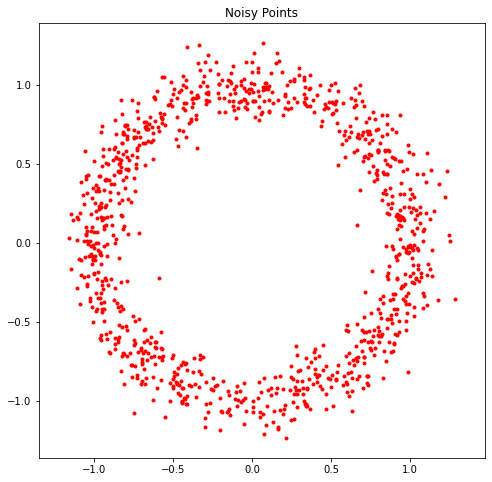

In [119]:
def generate_points(n):
    angles = np.random.uniform(0, 2*np.pi, n)
    x = np.cos(angles)
    y = np.sin(angles)
    return x, y

def add_noise(points, sigma):
    noise_x = np.random.normal(scale=sigma, size=points[0].shape)
    noise_y = np.random.normal(scale=sigma, size=points[1].shape)
    noisy_points = np.array([points[0] + noise_x, points[1] + noise_y])
    noisy_points = np.transpose(noisy_points)
    return noisy_points

n = 1000
sigma = 0.1

points = generate_points(n)
noisy_points = add_noise(points, sigma)

plt.figure(figsize=(8, 8))
plt.plot(noisy_points[:, 0], noisy_points[:, 1], 'ro', markersize=3)
plt.axis('equal')
plt.title('Noisy Points')
plt.show()

In [120]:
c_0 = np.array([1, 3])
r_0 = 2
t = 0.1
n= 1000

points = generate_points(n)
noisy_points = add_noise(points, 0.1)

print(newton(c_0, r_0, noisy_points, t))

[[0.61155808 1.81053325 1.98998154]]


<ipython-input-117-1ade7fbed04f>:2: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  h_11 = np.sum(1 - (r/np.linalg.norm(c-x)**2)*(np.linalg.norm(c-x)-(c[0]-x[0])**2/np.linalg.norm(c-x)) for x in points)
<ipython-input-117-1ade7fbed04f>:3: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  h_12 = np.sum((r*(c[0]-x[0])*(c[1]-x[1]))/np.linalg.norm(c-x)**3 for x in points)
<ipython-input-117-1ade7fbed04f>:4: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  h_13 = np.sum(-(c[0]-x[0])/np.linalg.norm(c-x) for x in points)
<ipython-input-117-1ade7fbed04f>:5: DeprecationWarning: Calling np.sum(generator) is